# Active photonics beyond 3-WL

[The passive companion notebook](beyond_1wl.ipynb) interprets a graph
as an `optyx.interaction.CMap` of linear-optical cells — every node is
a channel that inputs one photon per tick — and separates
non-isomorphic graphs that no message-passing GNN can tell apart, the
1-WL bound of [Xu et al., ICLR 2019](https://arxiv.org/abs/1810.00826)
and [Morris et al., AAAI 2019](https://arxiv.org/abs/1810.02244). It
also measures where *passive* linear optics stops: the 4x4 rook's
graph against the Shrikhande graph, the smallest pair of strongly
regular graphs with the same parameters srg(16, 6, 2, 2). No k-WL
test with `k <= 3` distinguishes two strongly regular graphs with the
same parameters (Cai, Fürer & Immerman, Combinatorica 1992;
[Arvind et al.](https://arxiv.org/abs/1811.04801)), and the passive
statistics are stuck for a reason of their own: the two
single-particle transfer matrices agree up to an output relabelling
and a phase per injection, every photon-counting probability of
non-interacting photons is a permanent modulus, and permanent moduli
are invariant under both.

This notebook makes the photonics **active**. Each cell watches its
tap with a threshold detector, stores the outcome in a classical bit,
and — this is the part that matters — *broadcasts the click to its
neighbours along the edges*, whose stored bits then re-program an
optical element in their cells for the rest of the run. Measurement
and feed-forward is the resource that makes linear optics
computationally universal (Knill, Laflamme & Milburn, Nature 409,
2001), so no fixed k-WL bounds active photonics in principle; what
this notebook measures is where the boundary actually sits for this
encoding:

1. with the feed-forward **off**, the homogeneously driven two-photon
   statistics of rook and Shrikhande agree *exactly* — the gauge
   argument, observed at machine precision;
2. with each detection re-programming **only its own cell**, they
   still agree exactly: the strong regularity that defeats 3-WL also
   absorbs a single marked vertex;
3. with each detection broadcast **one hop along the edges**, the
   statistics separate — the classical layer writes the local graph
   structure into the optics (the neighbourhood of a vertex induces
   two triangles in the rook's graph and a hexagon in Shrikhande's:
   the smallest 1-WL-equivalent pair, which the passive optics
   already tells apart).

Quantum models beyond 1-WL have a history. Walk-based spectra pass
1-WL on many strongly regular pairs
([Emms, Hancock, Severini & Wilson](https://arxiv.org/abs/quant-ph/0701033)),
yet both they and the interacting-walker invariants factor through the
graph's *cellular algebra*
([Smith](https://arxiv.org/abs/1103.0262)) — a Weisfeiler-Leman-style
ceiling of their own, of which the single-marked-cell blindness
measured below is an instance. On the learning side, equivariant
quantum graph circuits are universal approximators over bounded graphs
([Mernyei, Meichanetzidis & Ceylan, ICML 2022](https://arxiv.org/abs/2112.05261)),
and the message-passing QGNN of
[Raj, Coyle, Monbroussou, Ferreira-Martins, Farias & Kashefi](https://arxiv.org/abs/2606.26873)
provably matches *set-based* j-WL at node-register particle number
`j <= 4` — which, since set-based j-WL coincides with the standard
(j-1)-WL on tuples, is a proven ceiling of tuple 3-WL, one level short
of the strongly regular pairs — reached by a purely unitary circuit
initialised with the isomorphism types of the 4-vertex induced
subgraphs. The mechanism measured here sits outside all of these:
measurement and classical feed-forward in the loop, on hardware with
no qubits at all.

Everything is defined here — the cells, an exact simulator of the
post-selected two-photon sector, and its validation against optyx's
own contraction of `CMap.unroll`. Only `optyx`, `numpy` and
`networkx` are used.

In [1]:
from itertools import combinations, product
from math import comb

import networkx as nx
import numpy as np

from optyx.channel import qmode, bit, Diagram
from optyx.interaction import Box, CMap
from optyx.photonic import Create, Gate, TBS
from optyx import photonic, classical

## The pair, certified

Both graphs are 6-regular on 16 vertices with the same strongly
regular parameters; 1-WL colour refinement stabilises to the same
colouring, and they are not isomorphic. The difference that will end
up mattering is local: the six neighbours of any vertex induce two
triangles in the rook's graph and a six-cycle in Shrikhande's.

In [2]:
def rook():
    """The 4x4 rook's graph: same row or same column."""
    return tuple(
        tuple(sorted(4 * a + b for a, b in product(range(4), range(4))
                     if (a == i) != (b == j)))
        for i, j in product(range(4), range(4)))

def shrikhande():
    """The Cayley graph of Z4 x Z4 with connection set
    {(1,0), (0,1), (1,1)} and inverses."""
    steps = ((1, 0), (3, 0), (0, 1), (0, 3), (1, 1), (3, 3))
    return tuple(
        tuple(sorted(4 * ((i + a) % 4) + (j + b) % 4
                     for a, b in steps))
        for i, j in product(range(4), range(4)))

def cycle(n):
    return tuple(tuple(sorted(((i - 1) % n, (i + 1) % n)))
                 for i in range(n))

def path(n):
    return tuple(tuple(j for j in (i - 1, i + 1) if 0 <= j < n)
                 for i in range(n))

def wl_colours(graph):
    colours = [0] * len(graph)
    for _ in range(len(graph)):
        keys = [(colours[v], tuple(sorted(colours[u] for u in nbrs)))
                for v, nbrs in enumerate(graph)]
        table = {key: c for c, key in enumerate(sorted(set(keys)))}
        refined = [table[key] for key in keys]
        if refined == colours:
            break
        colours = refined
    return sorted(colours)

def as_networkx(graph):
    return nx.Graph(
        [(u, v) for u, nbrs in enumerate(graph) for v in nbrs])

assert wl_colours(rook()) == wl_colours(shrikhande())
assert not nx.is_isomorphic(as_networkx(rook()),
                            as_networkx(shrikhande()))
print("1-WL equivalent, not isomorphic; a rook neighbourhood has",
      nx.number_connected_components(
          as_networkx(rook()).subgraph(rook()[0])),
      "components (2C3), a Shrikhande neighbourhood has",
      nx.number_connected_components(
          as_networkx(shrikhande()).subgraph(shrikhande()[0])),
      "(C6)")

1-WL equivalent, not isomorphic; a rook neighbourhood has 2 components (2C3), a Shrikhande neighbourhood has 1 (C6)


## The passive cell, and its step matrix assembled directly

The optical hardware is the passive cell of the companion notebook: a
port-symmetric interferometer on the drive, the message ports and a
coherent memory, and a beam-splitter tap into a fresh vacuum mode as
the prediction.

One tick of the whole graph is a single unitary on the physical modes
— the drives and the memory — and rather than contracting
`CMap.step.to_path()` on a 16-vertex graph (minutes), we assemble the
same matrix directly: one block per cell from the cell's own path
matrix, glued by the read/write routing of the map, where each paired
port writes to the memory slot read by its partner at the next tick.
The assembly is checked *exactly* against `CMap.step.to_path()` on
small graphs, for both tap settings, so every later use of an
assembled matrix — kicked ones included — is grounded in the `CMap`
semantics.

In [3]:
def coupler(degree, theta=0.4, phi=0.7, chi=1.1, drive=0.8):
    modes = degree + 2
    ports, memory = range(1, degree + 1), modes - 1
    coupling = np.zeros((modes, modes), dtype=complex)
    for port in ports:
        coupling[port, memory] = theta * np.exp(1j * phi) / degree ** .5
        coupling[0, port] = 0.25 * np.exp(1j * 0.5) / degree ** .5
        for other in ports:
            if port != other:
                coupling[port, other] = chi / degree
    coupling[0, memory] = drive * np.exp(1j * 0.3)
    coupling[memory, memory] = 0.9
    coupling += np.triu(coupling, 1).conj().T
    energies, modes_ = np.linalg.eigh(coupling)
    return modes_ @ np.diag(np.exp(1j * energies)) @ modes_.conj().T

def vertex_box(degree, tap=0.3):
    modes = degree + 2
    mix = Gate(coupler(degree), modes, modes, f"mix{degree}")
    channel = mix >> Diagram.id(qmode ** (modes - 1)) @ (
        qmode @ Create(0) >> TBS(tap))
    return Box(f"cell{degree}", qmode, qmode ** degree, channel,
               memory=qmode, prediction=qmode)

def graph_cmap(graph, tap=0.3):
    return CMap(
        [vertex_box(len(nbrs), tap) for nbrs in graph],
        [((u, nbrs.index(v) + 1), (v, graph[v].index(u) + 1))
         for u, nbrs in enumerate(graph) for v in nbrs if u < v])

def box_matrix(degree, tap, cache={}):
    key = (degree, round(tap, 12))
    if key not in cache:
        box = vertex_box(degree, tap)
        array = np.asarray(box.channel.to_path().array, dtype=complex)
        cache[key] = array[:degree + 2, :]
    return cache[key]

def assemble(graph, taps):
    """The one-photon step matrix, cell b's tap set to taps[b].
    Rows: drives then memory (paired ports then internal memories);
    columns: drive reflections, predictions, then memory."""
    n = len(graph)
    pairs = [((u, graph[u].index(v) + 1), (v, graph[v].index(u) + 1))
             for u, nbrs in enumerate(graph) for v in nbrs if u < v]
    paired = [(u, j) for u, nbrs in enumerate(graph)
              for j in range(len(nbrs) + 1)
              if any((u, j) in edge for edge in pairs)]
    partner = {}
    for left, right in pairs:
        partner[left], partner[right] = right, left
    slot = {port: k for k, port in enumerate(paired)}
    n_paired = len(paired)
    matrix = np.zeros((n + n_paired + n, 2 * n + n_paired + n),
                      dtype=complex)

    def row(b, j, degree):
        return (b if j == 0 else n + slot[(b, j)] if j <= degree
                else n + n_paired + b)

    def column(b, j, degree):
        return (b if j == 0
                else 2 * n + slot[partner[(b, j)]] if j <= degree
                else 2 * n + n_paired + b if j == degree + 1
                else n + b)

    for b, nbrs in enumerate(graph):
        degree = len(nbrs)
        block = box_matrix(degree, taps[b])
        for j in range(degree + 2):
            for k in range(degree + 3):
                matrix[row(b, j, degree),
                       column(b, k, degree)] += block[j, k]
    return matrix

for graph in (cycle(3), path(3)):
    for tap in (0.3, 0.5):
        cmap = graph_cmap(graph, tap)
        exact = np.asarray(cmap.step.to_path().array, dtype=complex)[
            :len(cmap.dom) + len(cmap.memory), :]
        assert np.abs(assemble(graph, [tap] * len(graph))
                      - exact).max() < 1e-14
print("assembled step matrix == CMap.step.to_path(), both taps")

assembled step matrix == CMap.step.to_path(), both taps


## The cell with classical feed-forward

The active cell extends every wire that can carry it by a classical
`bit`: the message ports become `qmode @ bit` — a coherent message
*and* a classical message per edge — and the memory becomes
`qmode @ bit`, a coherent mode and a stored classical bit. Inside one
tick:

- the incoming edge bits and the stored bit are OR-ed into a
  **control** bit — this cell has clicked before, or a neighbour has;
- the control drives a `classical.BitControlledGate` holding a second
  beam splitter on the memory: the *kick* that re-programs the cell's
  tap;
- the tap output is watched by a threshold detector
  (`photonic.PhotonThresholdMeasurement`); the click is copied to
  every outgoing edge bit — the **broadcast** — to the prediction,
  and OR-ed with the control into the new stored bit, which latches.

Drawn as a stateful channel with the photon source `Create(1)` and
the whole `qmode @ bit` memory fed back through the loop:

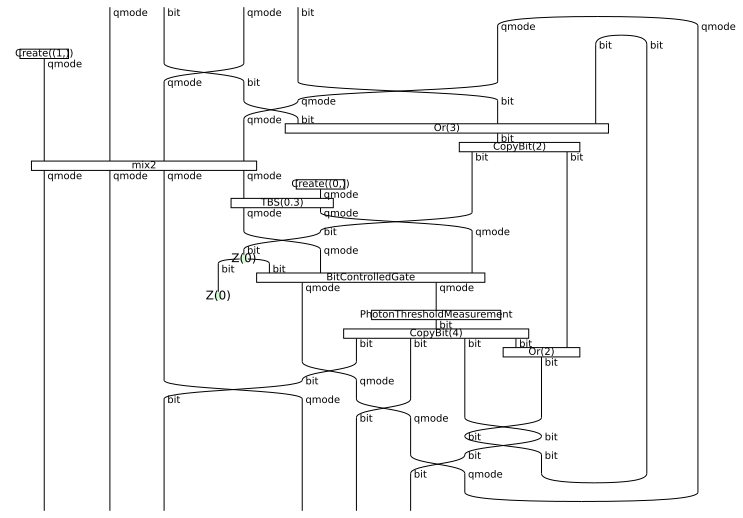

In [4]:
def active_vertex_box(degree, tap=0.3, kick=0.5):
    modes = degree + 2
    mix = Gate(coupler(degree), modes, modes, f"mix{degree}")
    source = qmode @ (qmode @ bit) ** degree @ (qmode @ bit)
    sort = Diagram.permutation(
        [0] + [1 + 2 * j for j in range(degree)] + [1 + 2 * degree]
        + [2 + 2 * j for j in range(degree)] + [2 + 2 * degree],
        source)
    channel = (
        sort
        >> Diagram.id(qmode ** modes) @ classical.Or(degree + 1)
        >> Diagram.id(qmode ** modes) @ classical.CopyBit(2)
        >> mix @ bit @ bit
        >> Diagram.id(qmode ** (modes - 1))
        @ (qmode @ Create(0) >> TBS(tap)) @ bit @ bit
        >> Diagram.id(qmode ** (modes - 1))
        @ Diagram.swap(qmode ** 2, bit) @ bit
        >> Diagram.id(qmode ** (modes - 1))
        @ classical.BitControlledGate(TBS(kick)) @ bit
        >> Diagram.id(qmode ** modes)
        @ photonic.PhotonThresholdMeasurement() @ bit
        >> Diagram.id(qmode ** modes)
        @ classical.CopyBit(degree + 2) @ bit
        >> Diagram.id(qmode ** modes @ bit ** (degree + 1))
        @ classical.Or(2))
    n_wires = modes + degree + 2
    gather = ([0] + [i for j in range(degree)
                     for i in (1 + j, modes + j)]
              + [modes - 1, n_wires - 1, modes + degree])
    channel = channel >> Diagram.permutation(gather, channel.cod)
    return Box(f"active{degree}", qmode, (qmode @ bit) ** degree,
               channel, memory=qmode @ bit, prediction=bit)

def stateful_channel(box, input_state=None):
    channel, dom = box.channel, box.ports
    if input_state is not None:
        channel = input_state @ Diagram.id(
            box.cod @ box.memory) >> channel
        dom = box.cod
    move_memory_last = Diagram.id(box.ports) @ Diagram.swap(
        box.memory, box.prediction)
    return (channel >> move_memory_last).feedback(
        dom=dom, cod=box.ports @ box.prediction, mem=box.memory)

active = active_vertex_box(2)
assert active.memory == qmode @ bit and active.prediction == bit
stateful_channel(active, Create(1)).draw(figsize=(10, 7))

## Every cell inputs one photon per tick, and what can be simulated

In the model, *every* cell is driven identically — one photon into
every drive at every tick, as the drawing above shows for a single
box; there is no designated source and nothing breaks the symmetry
except the graph itself. The passive version of that fully driven
network stays classically computable at every order, because
non-interacting statistics are permanents of the single-particle
transfer matrix. The *active* version does not: with measurement and
feed-forward in the loop, linear optics is computationally universal
(KLM), so an efficient exact classical simulation of the fully driven
network is not to be expected — that hardness is the same coin as the
expressive power being measured.

What can be computed exactly is the **few-photon sector** of the same
homogeneous drive. Attenuate the pump: each cell's source becomes a
heralded single-photon source firing with a small probability per
tick, still identical at every cell. Post-select the runs where
exactly two heralds fired, in the same pulse. The record statistics
of that ensemble are the *uniform average over injection pairs* of
the exact two-photon conditioned dynamics — an incoherent mixture,
since the heralds say which cells fired. That average is what the
simulator below computes, branching over the classical detection
records: within one branch the photons evolve under the assembled
step matrix of the *kicked* graph, where every cell whose control bit
is set has its tap at the kicked value; branches never re-interfere,
because their records are orthogonal pointer states.

**Convention.** A branch with `k` photons is a symmetric rank-`k`
tensor over the physical modes whose ordered sum of squared moduli is
the branch probability; detecting photons at measured wires
`w_1 <= ... <= w_d` leaves `sqrt(k!/((k-d)! prod(occ!)))` times the
slice as the conditioned tensor. The readout is binned
isomorphism-invariantly: detection times, the graph relations of each
detected cell to the two injection cells, and the pairwise relations
between detected cells.

In [5]:
EINSUM = {1: "a,ai->i", 2: "ab,ai,bj->ij"}

class Machine:
    """A graph's step matrices, plain and kicked. A detection at
    cell c re-programs the taps of c and, when ``broadcast``, of its
    neighbours, from the next tick on."""

    def __init__(self, graph, tap=0.3, kicked_tap=0.5,
                 broadcast=True):
        self.graph, self.tap, self.kicked_tap = graph, tap, kicked_tap
        self.broadcast = broadcast
        n = self.n = len(graph)
        self.S = assemble(graph, [tap] * n)
        self.n_in = self.S.shape[0]
        self.n_meas = 2 * n
        self.cell_of_wire = list(range(n)) + list(range(n))
        self.adj = [set(nbrs) for nbrs in graph]
        self.cache = {}

    def step(self, kicked):
        region = set()
        for cell in kicked:
            region |= {cell} | (self.adj[cell] if self.broadcast
                                else set())
        key = frozenset(region)
        if key not in self.cache:
            taps = [self.tap] * self.n
            for cell in key:
                taps[cell] = self.kicked_tap
            self.cache[key] = assemble(self.graph, taps)
        return self.cache[key]

    def rel(self, c, u):
        return 0 if c == u else 1 if c in self.adj[u] else 2

def detections(n_meas, d):
    """Sorted d-tuples of measured wires, with d!/prod(occ!)."""
    if d == 1:
        return [((w,), 1) for w in range(n_meas)]
    return [((w1, w2), 2 if w1 != w2 else 1)
            for w1 in range(n_meas) for w2 in range(w1, n_meas)]

def run_pair(machine, u, v, n_ticks, raw=False):
    """The record distribution for one photon in each of the drives
    u and v at tick 0."""
    n_meas, n_in = machine.n_meas, machine.n_in
    K = slice(n_meas, None)
    bins = {}

    def add(record, left, p):
        key = (record, left) if raw             else invariant_key(machine, u, v, record, left)
        bins[key] = bins.get(key, 0.0) + p

    A = np.zeros((n_in, n_in), dtype=complex)
    A[u, v] = A[v, u] = 1 / 2 ** .5
    branches = {(): (frozenset(), A)}
    for t in range(n_ticks):
        new = {}
        for record, (kicked, A) in branches.items():
            k = A.ndim
            S = machine.step(kicked)
            B = np.einsum(EINSUM[k], A, *([S] * k), optimize=True)
            keep = B[(K,) * k]
            if (np.abs(keep) ** 2).sum() > 1e-24:
                full = np.zeros((n_in,) * k, dtype=complex)
                full[(slice(machine.n, None),) * k] = keep
                new[record] = (kicked, full)
            for d in range(1, k + 1):
                for wires, mult in detections(n_meas, d):
                    amp = (mult * comb(k, d)) ** .5                         * B[wires + (K,) * (k - d)]
                    weight = (np.abs(amp) ** 2).sum() if k > d                         else np.abs(amp) ** 2
                    if weight <= 1e-24:
                        continue
                    rec = record + tuple((t, w) for w in wires)
                    if k == d:
                        add(rec, 0, float(np.abs(amp) ** 2))
                    else:
                        cells = frozenset(
                            machine.cell_of_wire[w] for w in wires)
                        full = np.zeros(n_in, dtype=complex)
                        full[machine.n:] = amp
                        new[rec] = (kicked | cells, full)
        branches = new
    for record, (kicked, A) in branches.items():
        p = float((np.abs(A) ** 2).sum())
        if p > 1e-24:
            add(record, A.ndim, p)
    return bins

def invariant_key(machine, u, v, record, left):
    """Detection times, the relations of each detected cell to the
    injection pair, the pairwise relations between detected cells,
    and the number of photons left inside."""
    cells = [machine.cell_of_wire[w] for _, w in record]
    times = [t for t, _ in record]
    singles = tuple(sorted(
        (t, tuple(sorted((machine.rel(c, u), machine.rel(c, v)))))
        for t, c in zip(times, cells)))
    pairs = tuple(sorted(
        (min(times[i], times[j]), max(times[i], times[j]),
         machine.rel(cells[i], cells[j]))
        for i in range(len(cells)) for j in range(i + 1, len(cells))))
    return (left, singles, pairs)

total = sum(run_pair(Machine(cycle(3)), 0, 1, 4).values())
assert abs(total - 1) < 1e-9
print(f"two photons on C3, kick on: total probability {total:.12f}")

two photons on C3, kick on: total probability 1.000000000000


## Validation against the contraction of `CMap.unroll`

On the smallest map — one edge, one photon in each drive, two ticks,
kick off — the simulator's joint distribution over the detected
counts must match optyx's doubled quimb contraction of the unrolled
channel with every output measured, entry by entry. It does, to
machine precision (`unroll` discards its memory, so the photons still
inside are marginalised on both sides); the active runs differ only
in *which* assembled — and equally validated — step matrix each
branch uses.

In [6]:
def joint_simulator(graph, n_ticks):
    machine = Machine(graph, kicked_tap=0.3)
    bins = run_pair(machine, 0, 1, n_ticks, raw=True)
    joint = {}
    for (record, left), p in bins.items():
        counts = [0] * (n_ticks * machine.n_meas)
        for t, w in record:
            counts[t * machine.n_meas + w] += 1
        joint[tuple(counts)] = joint.get(tuple(counts), 0.0) + p
    return joint

def joint_optyx(graph, n_ticks):
    from optyx.channel import Measure
    cmap = graph_cmap(graph)
    ticks = [Diagram.id().tensor(*[
        Create(1 if t == 0 else 0) for _ in range(len(graph))])
        for t in range(n_ticks)]
    memory = Diagram.id().tensor(*[
        Create(0) for _ in range(len(cmap.memory))])
    unrolled = Diagram.id().tensor(*ticks) @ memory         >> cmap.unroll(n_ticks - 1)
    tensor = (unrolled >> Measure(unrolled.cod)).eval().tensor
    return np.asarray(tensor.array).real.reshape(
        tuple(int(dim) for dim in tensor.cod.inside))

simulated = joint_simulator(path(2), 2)
contracted = joint_optyx(path(2), 2)
worst = max(abs(contracted[counts] - simulated.get(counts, 0.0))
            for counts in np.ndindex(contracted.shape))
assert worst < 1e-12
print(f"worst joint-probability mismatch against optyx: {worst:.1e}")

worst joint-probability mismatch against optyx: 2.8e-17


## The experiment

The post-selected two-herald ensemble: the uniform average, over the
120 unordered pairs of cells, of the invariantly binned record
distribution. The separation between rook and Shrikhande is the
largest difference between the two ensembles, bin by bin — no sorting
and no designated source, so the readout is manifestly a graph
invariant. Twelve ticks; three feed-forward settings.

In [7]:
def aggregate(graph, n_ticks, **settings):
    machine = Machine(graph, **settings)
    total = {}
    pairs = list(combinations(range(len(graph)), 2))
    for u, v in pairs:
        for key, p in run_pair(machine, u, v, n_ticks).items():
            total[key] = total.get(key, 0.0) + p / len(pairs)
    return total

def separation(left, right, n_ticks, **settings):
    one = aggregate(left, n_ticks, **settings)
    two = aggregate(right, n_ticks, **settings)
    return float(max(abs(one.get(key, 0.0) - two.get(key, 0.0))
                     for key in set(one) | set(two)))

margins = {}
for label, settings in [
        ("kick off", dict(kicked_tap=0.3)),
        ("own cell only", dict(broadcast=False)),
        ("one-hop broadcast", dict())]:
    margins[label] = separation(rook(), shrikhande(), 12, **settings)
    print(f"{label:18}: separation {margins[label]:.6e}")
assert margins["kick off"] < 1e-12
assert margins["own cell only"] < 1e-12
assert margins["one-hop broadcast"] > 3e-4
print(f"shots per post-selected pair at five sigma: "
      f"{(5 / margins['one-hop broadcast']) ** 2:.1e}")

kick off          : separation 6.938894e-18


own cell only     : separation 6.938894e-18


one-hop broadcast : separation 1.685602e-03
shots per post-selected pair at five sigma: 8.8e+06


In [8]:
for ticks in (8, 10, 12):
    print(f"T={ticks}: "
          f"{separation(rook(), shrikhande(), ticks):.6e}")

T=8: 7.837091e-04


T=10: 1.607115e-03


T=12: 1.685602e-03


In [9]:
permutation = list(np.random.default_rng(1).permutation(16))
inverse = [permutation.index(i) for i in range(16)]
relabelled = tuple(
    tuple(sorted(permutation[x] for x in rook()[inverse[i]]))
    for i in range(16))
invariance = separation(rook(), relabelled, 8)
assert invariance < 1e-12
print(f"largest ensemble change under a relabelling: "
      f"{invariance:.1e}")

largest ensemble change under a relabelling: 6.9e-18


## Which k-WL separates with passive against active photonics

| model | bound | measured |
|---|---|---|
| decohered walk, GNN, MapNN | 1-WL, provably (Xu et al.; Morris et al.) | exactly blind on every 1-WL-equivalent pair; separates the control (companion notebook) |
| passive coherent photonics | beyond 1-WL, but blind to same-parameter strongly regular pairs — the pairs on which every k-WL with k ≤ 3 fails too | separates 2C3/C6, 2C6/C12, decalin/bicyclopentyl (companion); *exactly* blind on rook vs Shrikhande, here at machine precision |
| active, detection re-programs its own cell | still blind on this pair: strong regularity absorbs one marked vertex | exactly zero separation, at machine precision |
| active, detection broadcast one hop | separates the 3-WL-hard pair; in principle unbounded — feed-forward makes linear optics universal (KLM) | 1.7e-3 at twelve ticks (plateauing near a dozen ticks); ~9e6 post-selected pairs at five sigma |

The mechanism is worth stating plainly. Marking the cell that clicked
changes the optics, but every statistic this invariant readout can
see of a *single* marked vertex is fixed by the shared strongly
regular parameters — measured above as an exact zero: the quantum
side alone does not crack the pair. Broadcasting the click one hop
writes the *induced neighbourhood* into the optics, and there the two
graphs finally differ — two triangles against a hexagon — a
difference the passive optics already resolves. The classical
feed-forward layer is itself message passing, and it is the composite
— coherent interference through a classically re-programmed landscape
— that goes where neither layer goes alone. This mirrors how
individualisation-refinement escapes k-WL, and how the *interacting*
two-walker statistics of
[Gamble et al.](https://arxiv.org/abs/1002.3003) separate strongly
regular pairs that non-interacting walkers cannot.

The same boundary locates this model in the current landscape. The
message-passing QGNN of
[Raj et al.](https://arxiv.org/abs/2606.26873) climbs the hierarchy by
state-space design — a node register at particle number j spans the
j-subsets of vertices, one unitary layer performs one round of
set-based j-WL, proved for `j <= 4` because its closed-walk
initialisation stops fixing induced subgraphs at five vertices — and
since set-based j-WL equals (j-1)-WL on tuples, its proven power tops
out at tuple 3-WL: exactly below the strongly regular pairs, which its
purely unitary layers cannot reach. The walk spectra of
[Emms et al.](https://arxiv.org/abs/quant-ph/0701033) that pass 1-WL
are in turn bounded by the graph's cellular algebra
([Smith](https://arxiv.org/abs/1103.0262)) — the theorem-shaped
counterpart of the single-cell blindness measured above. The
separation here uses neither higher-order registers nor an
initialisation oracle: the graph enters only through the physical
wiring, and the resource that crosses the boundary is measurement with
classical feed-forward — unavailable inside a unitary circuit, native
to a `CMap` whose wires type classical bits beside quantum modes.

Three honest caveats. The separation is a measurement on one pair —
the smallest 3-WL-hard one — not a theorem covering some k; the
general statements in the table are the quoted known bounds. The
exact zeros are exact for this readout: finer invariant binnings of
the same records can resolve hairline differences even passively
(the gauge's output relabelling is not a graph map), but none we
measured becomes practical without the broadcast. And the simulated
sector holds two photons at a time — the exactly computable slice of
the homogeneous drive — while the full one-photon-per-cell-per-tick
network compounds the same mechanism beyond classical simulation,
which is exactly what the KLM universality of
measurement-and-feed-forward promises.